## Model Loading

In [14]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart/Pre/ngraphs-8_nnodes-8_gdim-128_nheads-1_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-0.2_target_data-Medicaldataset_description-asdasd/42/best.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart/Pre/ngraphs-8_nnodes-8_gdim-128_nheads-1_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-0.2_target_data-Medicaldataset_description-asdasdasdasd/42/best.pt"
#ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart/Pre/ngraphs-8_nnodes-8_gdim-128_nheads-1_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-0.2_target_data-Medicaldataset_description-asdasdasdasdasd/42/best.pt"
ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/heart/Pre/ngraphs-8_nnodes-8_gdim-128_nheads-1_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-0.2_target_data-heart_description-encodertest1/42/best.pt"
# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


Missing keys: []
Unexpected keys: []


Model(
  (basis_layers): ModuleList(
    (0-1): 2 x BasisGATLayer_IND(
      (attn_dropout): Dropout(p=0.1, inplace=False)
      (q_proj_list): ModuleList(
        (0): Linear(in_features=768, out_features=768, bias=True)
      )
      (k_proj_list): ModuleList(
        (0): Linear(in_features=768, out_features=768, bias=True)
      )
      (v_proj_list): ModuleList(
        (0): Linear(in_features=768, out_features=768, bias=True)
      )
      (attn_proj_list): ModuleList(
        (0): Linear(in_features=2304, out_features=1, bias=True)
      )
      (edge_update): Sequential(
        (0): Linear(in_features=1536, out_features=768, bias=True)
        (1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
        (3): Linear(in_features=768, out_features=768, bias=True)
      )
    )
  )
  (basis_layer_norms): ModuleList(
    (0-1): 2 x LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (sheads): ModuleList(
    (0): Sequential(
      (0): LayerNorm((7

## Source Loading

In [15]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)


Loading dataloader for source: heart
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart.pkl
Training data size: 550
Validation data size: 184
Test data size: 184


In [16]:
import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings

import matplotlib.pyplot as plt
import numpy as np
import os
def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()


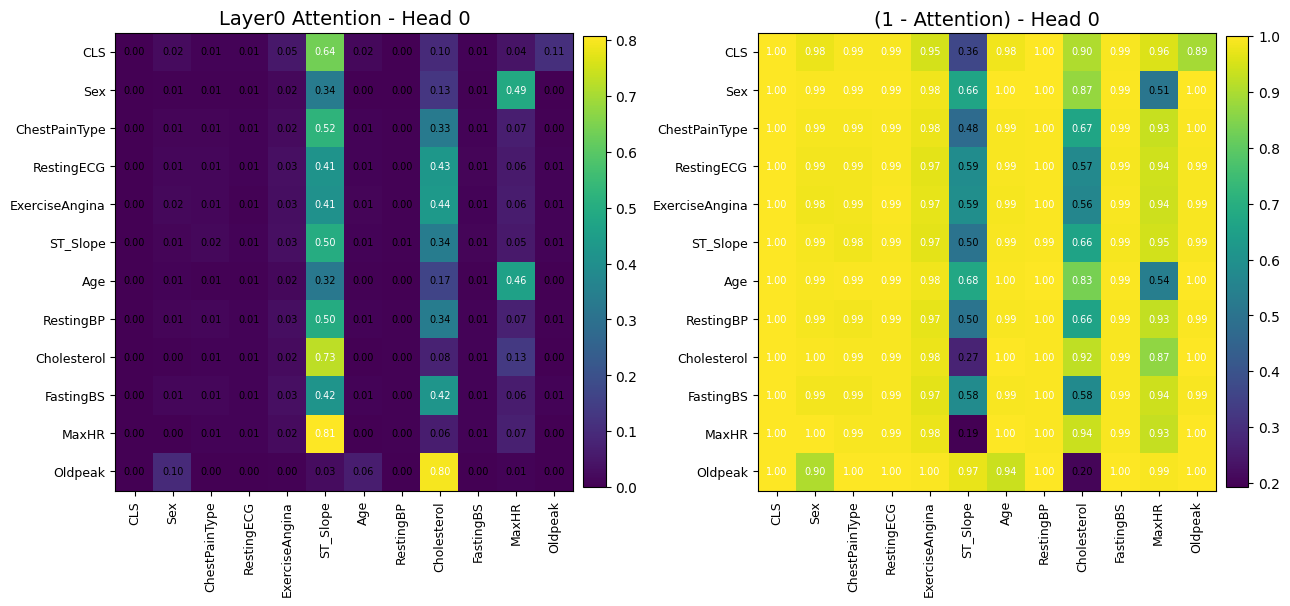

=== Embedding statistics per token (CLS + features) ===
            CLS  | mean=-0.0086 | std=0.4004
            Sex  | mean=0.0594 | std=2.6928
  ChestPainType  | mean=0.0599 | std=2.6938
     RestingECG  | mean=0.0425 | std=2.4687
 ExerciseAngina  | mean=0.0637 | std=2.7589
       ST_Slope  | mean=0.0538 | std=2.6591
            Age  | mean=-0.1135 | std=4.8134
      RestingBP  | mean=0.0675 | std=1.7838
    Cholesterol  | mean=-0.0075 | std=0.4913
      FastingBS  | mean=-0.1536 | std=3.3200
          MaxHR  | mean=0.4036 | std=9.0866
        Oldpeak  | mean=0.1226 | std=3.0981

=== Global embedding statistics ===
global mean: 0.0492
global std : 3.7129


In [17]:
src = sources[0]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)



=== Collecting Logits for ALL samples in heart ===


Scanning: 100%|██████████| 29/29 [00:00<00:00, 176.23it/s]


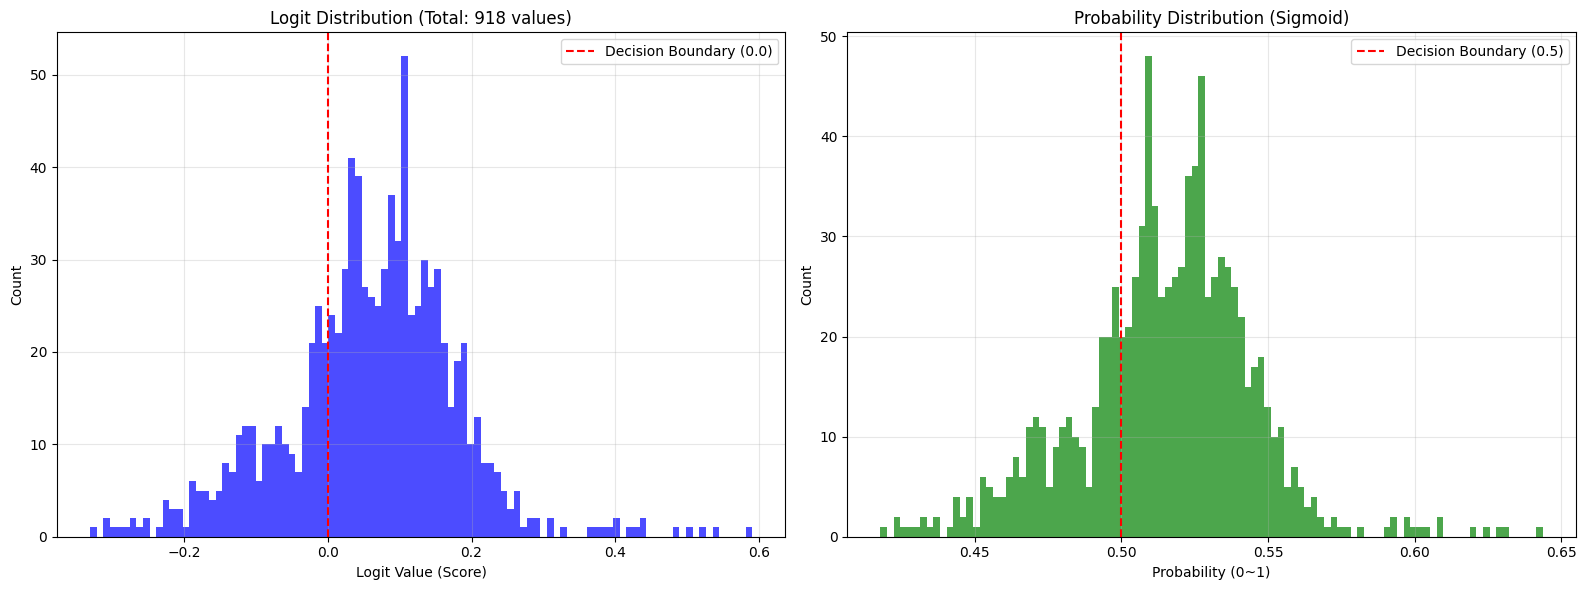


=== Distribution Summary ===
Total Values: 918
[Logit] Min: -0.3314, Max: 0.5910, Mean: 0.0598
[Logit] Std Dev: 0.1204
[Saturation Check] Logit > 5.0 or < -5.0 count: 0 (0.00%)


In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def plot_logit_distribution(model, loader, src_name):
    model.eval()
    device = model.device
    
    all_logits = []
    all_probs = []
    
    print(f"=== Collecting Logits for ALL samples in {src_name} ===")
    
    # 1. 전체 데이터 순회
    with torch.no_grad():
        for batch in tqdm(loader, desc="Scanning"):
            # 데이터 이동
            batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
            
            # 예측 (Logit)
            # model.predict가 있다면 사용, 없으면 직접 forward
            if hasattr(model, 'predict'):
                logits = model.predict(batch)
            else:
                # 만약 predict 함수가 없으면 기존 forward 로직 사용 (간소화)
                # (사용자님 코드 상황에 맞춰 predict가 있다고 가정합니다)
                pass 
            
            # Logit 수집
            # Multi-class인 경우, 예측된 클래스(argmax)의 Logit만 가져올지, 
            # 아니면 전체 Logit의 분포를 볼지 결정해야 함.
            # 여기서는 "모델이 내뱉는 모든 값의 스케일"을 보기 위해 전체를 다 넣습니다.
            all_logits.append(logits.cpu().numpy().flatten())
            all_probs.append(torch.sigmoid(logits).cpu().numpy().flatten())

    # 2. 데이터 병합
    all_logits = np.concatenate(all_logits)
    all_probs = np.concatenate(all_probs)
    
    # 3. 시각화 (좌: Logit, 우: Probability)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # (1) Logit Histogram
    axes[0].hist(all_logits, bins=100, color='blue', alpha=0.7)
    axes[0].set_title(f"Logit Distribution (Total: {len(all_logits)} values)")
    axes[0].set_xlabel("Logit Value (Score)")
    axes[0].set_ylabel("Count")
    axes[0].grid(True, alpha=0.3)
    # 0.0 기준선 (결정 경계)
    axes[0].axvline(0.0, color='red', linestyle='--', label='Decision Boundary (0.0)')
    axes[0].legend()

    # (2) Probability Histogram
    axes[1].hist(all_probs, bins=100, color='green', alpha=0.7)
    axes[1].set_title("Probability Distribution (Sigmoid)")
    axes[1].set_xlabel("Probability (0~1)")
    axes[1].set_ylabel("Count")
    axes[1].grid(True, alpha=0.3)
    axes[1].axvline(0.5, color='red', linestyle='--', label='Decision Boundary (0.5)')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # 4. 요약 통계 출력
    print("\n=== Distribution Summary ===")
    print(f"Total Values: {len(all_logits)}")
    print(f"[Logit] Min: {all_logits.min():.4f}, Max: {all_logits.max():.4f}, Mean: {all_logits.mean():.4f}")
    print(f"[Logit] Std Dev: {all_logits.std():.4f}")
    
    # Saturation 비율 확인 (절댓값이 5 이상인 경우)
    saturated_count = np.sum(np.abs(all_logits) > 5.0)
    print(f"[Saturation Check] Logit > 5.0 or < -5.0 count: {saturated_count} ({saturated_count/len(all_logits)*100:.2f}%)")

# --- 실행 ---
plot_logit_distribution(model, loaders[sources[0]], sources[0])

## Qualitative Analysis (1)

- Leave-One-Out variable independently
- top-k Leave-K-Out variables 
- 전체 Dataset에서, 특정 변수를 제외한 나머지를 가지고 구한 AUC

In [19]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# ----------------------------
# feature name (order-preserving, matches embedding order)
# ----------------------------
def feat_names(batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            s = str(t[0] if isinstance(t, tuple) else t)
            names.append(s.split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            s = str(t[0] if isinstance(t, tuple) else t)
            names.append(s.split(",")[0].split("'")[0])
    return names

# ----------------------------
# drop one variable token from a batch (hard node mask)
# idx: 0..(n_vars-1) over (cat vars + num vars)
# ----------------------------
def drop_var(batch, idx):
    b = dict(batch)  # shallow copy

    n_cat = b['cat_value_embeddings'].shape[1] if 'cat_value_embeddings' in b else 0
    in_cat = idx < n_cat
    j = idx if in_cat else (idx - n_cat)

    if in_cat:
        for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']:
            if k in b:
                x = b[k]
                b[k] = torch.cat([x[:, :j], x[:, j+1:]], dim=1)
        if 'cat_desc_texts' in b:
            t = list(b['cat_desc_texts'])
            b['cat_desc_texts'] = t[:j] + t[j+1:]
    else:
        for k in ['num_name_embeddings', 'num_prompt_embeddings', 'num_desc_embeddings']:
            if k in b:
                x = b[k]
                b[k] = torch.cat([x[:, :j], x[:, j+1:]], dim=1)
        if 'num_desc_texts' in b:
            t = list(b['num_desc_texts'])
            b['num_desc_texts'] = t[:j] + t[j+1:]

    return b

# ----------------------------
# eval AUC over loader, optionally dropping a variable idx
# ----------------------------
@torch.no_grad()
def eval_auc(model, loader, drop_idx=None, max_batches=None, src_idx=0):
    model.eval()
    yt, yp = [], []
    for bi, batch in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        # ✅ 핵심: source head 강제 사용
        batch = dict(batch)
        batch['src_idx'] = src_idx

        if drop_idx is not None:
            batch = drop_var(batch, drop_idx)

        pred = model.predict(batch)  # logits
        yt.extend(batch['y'].cpu().numpy().reshape(-1).tolist())
        yp.extend(torch.sigmoid(pred).cpu().numpy().reshape(-1).tolist())

    return roc_auc_score(np.array(yt), np.array(yp))

# ----------------------------
# wrap-up runner
# ----------------------------
def run_drop(model, loader, max_batches=None, src_idx=0):
    batch0 = next(iter(loader))
    names = feat_names(batch0)
    n_vars = len(names)

    base = eval_auc(model, loader, drop_idx=None, max_batches=max_batches, src_idx=src_idx)

    aucs = []
    for i in range(n_vars):
        aucs.append(eval_auc(model, loader, drop_idx=i, max_batches=max_batches, src_idx=src_idx))

    aucs = np.array(aucs)
    return {"base_auc": float(base), "names": names, "auc_drop": aucs, "delta": base - aucs}

# ----------------------------
# plotting (Modified to 1x2 Subplot)
# ----------------------------
def plot_drop(res, topk=None):
    base = res["base_auc"]
    names = np.array(res["names"])
    aucs = np.array(res["auc_drop"])
    d = np.array(res["delta"])

    order = np.argsort(-d)  # biggest drop first
    if topk is not None:
        order = order[:topk]

    # 그래프 너비 동적 조정 (두 개를 가로로 배치하므로 기존보다 넓게 설정)
    fig_width = max(20, 1.0 * len(order))
    
    # 1행 2열 subplot 생성
    fig, axes = plt.subplots(1, 2, figsize=(fig_width, 6))

    # 첫 번째 plot: AUC Drop Delta
    axes[0].bar(np.arange(len(order)), d[order])
    axes[0].set_xticks(np.arange(len(order)))
    axes[0].set_xticklabels(names[order], rotation=90)
    axes[0].set_ylabel("AUC drop (base - drop)")
    axes[0].set_title(f"Drop-one-variable AUC drop (base={base:.4f})")

    # 두 번째 plot: AUC Absolute Values
    axes[1].bar(np.arange(len(order)), aucs[order])
    axes[1].axhline(base, linestyle="--", color='red', label='Base AUC')
    axes[1].set_xticks(np.arange(len(order)))
    axes[1].set_xticklabels(names[order], rotation=90)
    axes[1].set_ylabel("AUC after drop")
    axes[1].set_title("AUC after dropping each variable")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# 사용 예시 (모델과 로더가 정의되어 있다고 가정)


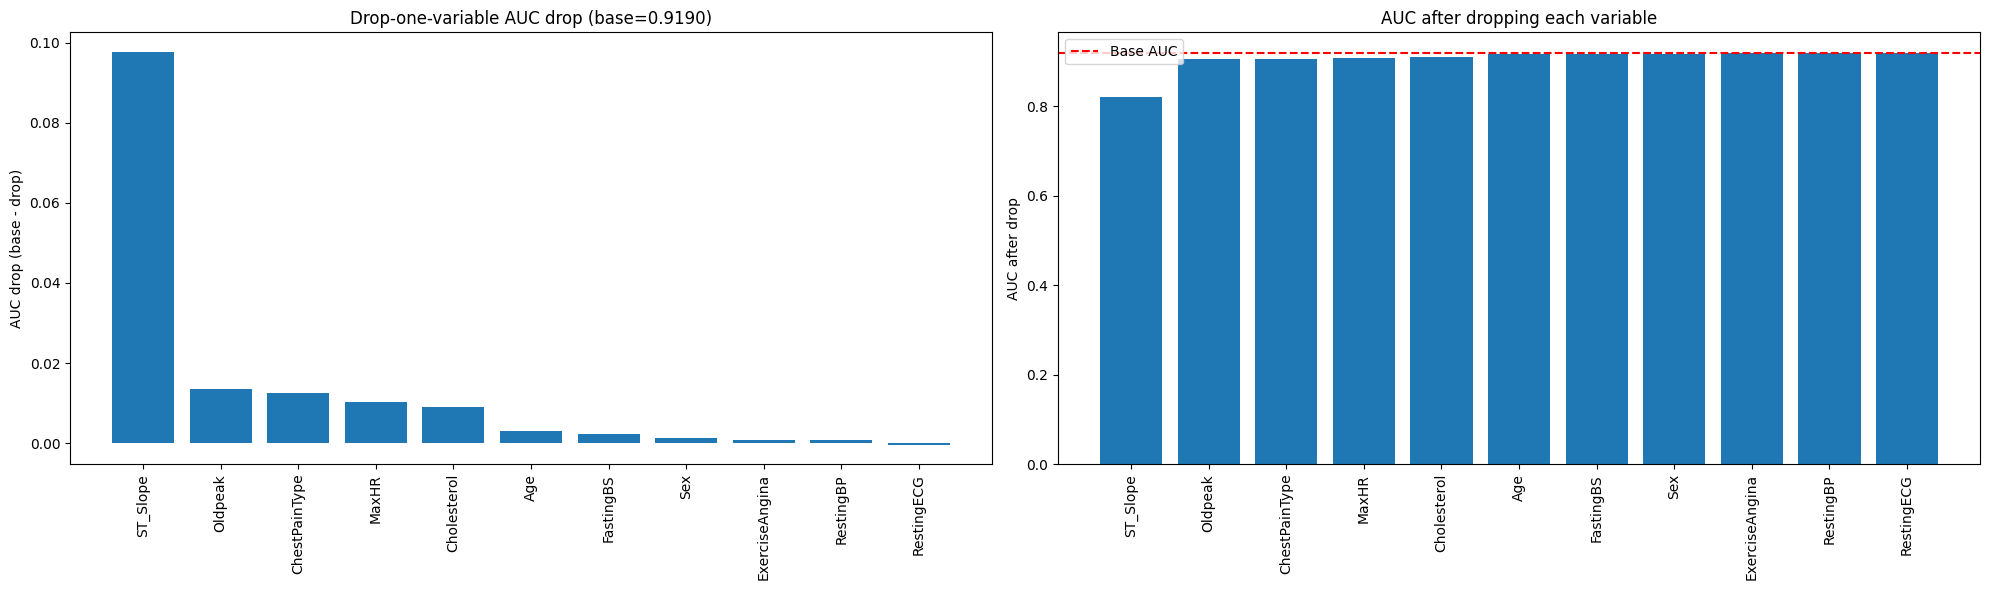

In [20]:
res = run_drop(model, loader, max_batches=None)
plot_drop(res, topk=20)


## Qualitative Analysis (2) 

- Baseline AUC
- Only topK Important features
- LO topK Important features 
- Only BottomK Important features
- LO BottomK Important features


## Qualitative Analysis (3) 
- Single Feature Replace with Baseline 

In [33]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

def feat_names(batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            s = str(t[0] if isinstance(t, tuple) else t)
            names.append(s.split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            s = str(t[0] if isinstance(t, tuple) else t)
            names.append(s.split(",")[0].split("'")[0])
    return names

def drop_var(batch, idx):
    b = dict(batch)
    n_cat = b['cat_value_embeddings'].shape[1] if 'cat_value_embeddings' in b else 0
    in_cat = idx < n_cat
    j = idx if in_cat else (idx - n_cat)

    if in_cat:
        for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']:
            if k in b:
                x = b[k]
                b[k] = torch.cat([x[:, :j], x[:, j+1:]], dim=1)
        if 'cat_desc_texts' in b:
            t = list(b['cat_desc_texts'])
            b['cat_desc_texts'] = t[:j] + t[j+1:]
    else:
        for k in ['num_name_embeddings', 'num_prompt_embeddings', 'num_desc_embeddings']:
            if k in b:
                x = b[k]
                b[k] = torch.cat([x[:, :j], x[:, j+1:]], dim=1)
        if 'num_desc_texts' in b:
            t = list(b['num_desc_texts'])
            b['num_desc_texts'] = t[:j] + t[j+1:]
    return b

def rep_var(batch, idx):
    # baseline replace: 해당 변수 value embedding만 "batch mean vector"로 치환 (토큰 수 유지)
    b = dict(batch)
    n_cat = b['cat_value_embeddings'].shape[1] if 'cat_value_embeddings' in b else 0
    in_cat = idx < n_cat
    j = idx if in_cat else (idx - n_cat)

    if in_cat and 'cat_value_embeddings' in b:
        x = b['cat_value_embeddings']
        base = x.mean(dim=1, keepdim=True)         # [B,1,D]
        x2 = x.clone()
        x2[:, j:j+1, :] = base
        b['cat_value_embeddings'] = x2

    if (not in_cat) and ('num_prompt_embeddings' in b):
        x = b['num_prompt_embeddings']
        base = x.mean(dim=1, keepdim=True)
        x2 = x.clone()
        x2[:, j:j+1, :] = base
        b['num_prompt_embeddings'] = x2

    return b

def keep_vars(batch, keep_idx):
    # delete 기반 subset(토큰 수 줄어듦) - 기존 그대로
    b = dict(batch)
    n_cat = b['cat_value_embeddings'].shape[1] if 'cat_value_embeddings' in b else 0
    keep_idx = list(keep_idx)

    cat_keep = [i for i in keep_idx if i < n_cat]
    num_keep = [i - n_cat for i in keep_idx if i >= n_cat]

    if n_cat > 0:
        cat_keep_t = torch.tensor(cat_keep, device=b['cat_value_embeddings'].device, dtype=torch.long)
        for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']:
            if k in b:
                b[k] = b[k].index_select(1, cat_keep_t)
        if 'cat_desc_texts' in b:
            t = list(b['cat_desc_texts'])
            b['cat_desc_texts'] = [t[i] for i in cat_keep]

    if 'num_prompt_embeddings' in b:
        num_keep_t = torch.tensor(num_keep, device=b['num_prompt_embeddings'].device, dtype=torch.long)
        for k in ['num_name_embeddings', 'num_prompt_embeddings', 'num_desc_embeddings']:
            if k in b:
                b[k] = b[k].index_select(1, num_keep_t)
        if 'num_desc_texts' in b:
            t = list(b['num_desc_texts'])
            b['num_desc_texts'] = [t[i] for i in num_keep]

    return b

def keep_rep(batch, keep_idx):
    # replace 기반 subset(토큰 수 유지): keep 이외 변수들을 baseline으로 치환
    b = dict(batch)
    keep = set(keep_idx)

    n_cat = b['cat_value_embeddings'].shape[1] if 'cat_value_embeddings' in b else 0
    n_num = b['num_prompt_embeddings'].shape[1] if 'num_prompt_embeddings' in b else 0

    if n_cat > 0 and 'cat_value_embeddings' in b:
        x = b['cat_value_embeddings']
        base = x.mean(dim=1, keepdim=True)
        x2 = x.clone()
        for j in range(n_cat):
            if j not in keep:
                x2[:, j:j+1, :] = base
        b['cat_value_embeddings'] = x2

    if n_num > 0 and 'num_prompt_embeddings' in b:
        x = b['num_prompt_embeddings']
        base = x.mean(dim=1, keepdim=True)
        x2 = x.clone()
        for j in range(n_num):
            g = n_cat + j
            if g not in keep:
                x2[:, j:j+1, :] = base
        b['num_prompt_embeddings'] = x2

    return b

@torch.no_grad()
def eval_auc(model, loader, drop_idx=None, mode="drop", src_idx=None):
    model.eval()
    yt, yp = [], []
    for batch in loader:
        if src_idx is not None:
            batch["src_idx"] = src_idx  # ✅ 핵심: sheads 강제

        if drop_idx is not None:
            batch = drop_var(batch, drop_idx) if mode == "drop" else rep_var(batch, drop_idx)

        pred = model.predict(batch)  # [B,1] logit
        yt.append(batch['y'].detach().cpu().numpy().reshape(-1))
        yp.append(torch.sigmoid(pred).detach().cpu().numpy().reshape(-1))

    yt = np.concatenate(yt, 0)
    yp = np.concatenate(yp, 0)
    return roc_auc_score(yt, yp)

@torch.no_grad()
def eval_auc_keep(model, loader, keep_idx, mode="drop", src_idx=None):
    model.eval()
    yt, yp = [], []
    for batch in loader:
        if src_idx is not None:
            batch["src_idx"] = src_idx  # ✅ 핵심: sheads 강제

        batch = keep_vars(batch, keep_idx) if mode == "drop" else keep_rep(batch, keep_idx)
        pred = model.predict(batch)

        yt.append(batch['y'].detach().cpu().numpy().reshape(-1))
        yp.append(torch.sigmoid(pred).detach().cpu().numpy().reshape(-1))

    yt = np.concatenate(yt, 0)
    yp = np.concatenate(yp, 0)
    return roc_auc_score(yt, yp)

def run_drop(model, loader, mode="drop", src_idx=None):
    batch0 = next(iter(loader))
    names = feat_names(batch0)
    n_vars = len(names)

    base = eval_auc(model, loader, drop_idx=None, mode=mode, src_idx=src_idx)
    aucs = np.array([eval_auc(model, loader, drop_idx=i, mode=mode, src_idx=src_idx) for i in range(n_vars)])
    d = base - aucs
    return {"base_auc": float(base), "names": names, "auc_drop": aucs, "delta": d, "mode": mode}

def run_kbars(model, loader, k=3, res=None, mode="drop", src_idx=None):
    if res is None:
        res = run_drop(model, loader, mode=mode, src_idx=src_idx)

    base = float(res["base_auc"])
    names = list(res["names"])
    delta = np.array(res["delta"])
    n = len(names)

    k = int(min(k, n))
    order = np.argsort(-delta)
    topk = sorted(order[:k].tolist())
    bottomk = sorted(order[-k:].tolist())

    all_idx = list(range(n))
    top_excl = [i for i in all_idx if i not in set(topk)]
    bot_excl = [i for i in all_idx if i not in set(bottomk)]

    auc_top_only = eval_auc_keep(model, loader, topk, mode=mode, src_idx=src_idx)
    auc_top_excl = eval_auc_keep(model, loader, top_excl, mode=mode, src_idx=src_idx)
    auc_bot_only = eval_auc_keep(model, loader, bottomk, mode=mode, src_idx=src_idx)
    auc_bot_excl = eval_auc_keep(model, loader, bot_excl, mode=mode, src_idx=src_idx)

    vals = [base, auc_top_only, auc_top_excl, auc_bot_only, auc_bot_excl]
    labs = ["Baseline", f"Top{k} only", f"Top{k} excl", f"Bottom{k} only", f"Bottom{k} excl"]

    plt.figure(figsize=(8,4))
    plt.bar(np.arange(len(vals)), vals)
    plt.xticks(np.arange(len(vals)), labs, rotation=20, ha="right")
    plt.ylim(0.0, 1.0)
    plt.ylabel("AUC")
    plt.title("AUC under variable subset interventions")
    plt.tight_layout()
    plt.show()

    return {
        "vals": vals,
        "labs": labs,
        "topk_names": [names[i] for i in topk],
        "bottomk_names": [names[i] for i in bottomk],
        "mode": mode,
    }


@torch.no_grad()
def eval_auc_keep(model, loader, keep_idx, mode="drop", src_idx=None):
    model.eval()
    yt, yp = [], []
    for batch in loader:
        if src_idx is not None:
            batch["src_idx"] = src_idx

        batch = keep_vars(batch, keep_idx) if mode == "drop" else keep_rep(batch, keep_idx)
        pred = model.predict(batch)

        yt.append(batch["y"].detach().cpu().numpy().reshape(-1))
        yp.append(torch.sigmoid(pred).detach().cpu().numpy().reshape(-1))

    yt = np.concatenate(yt, 0)
    yp = np.concatenate(yp, 0)
    return roc_auc_score(yt, yp)



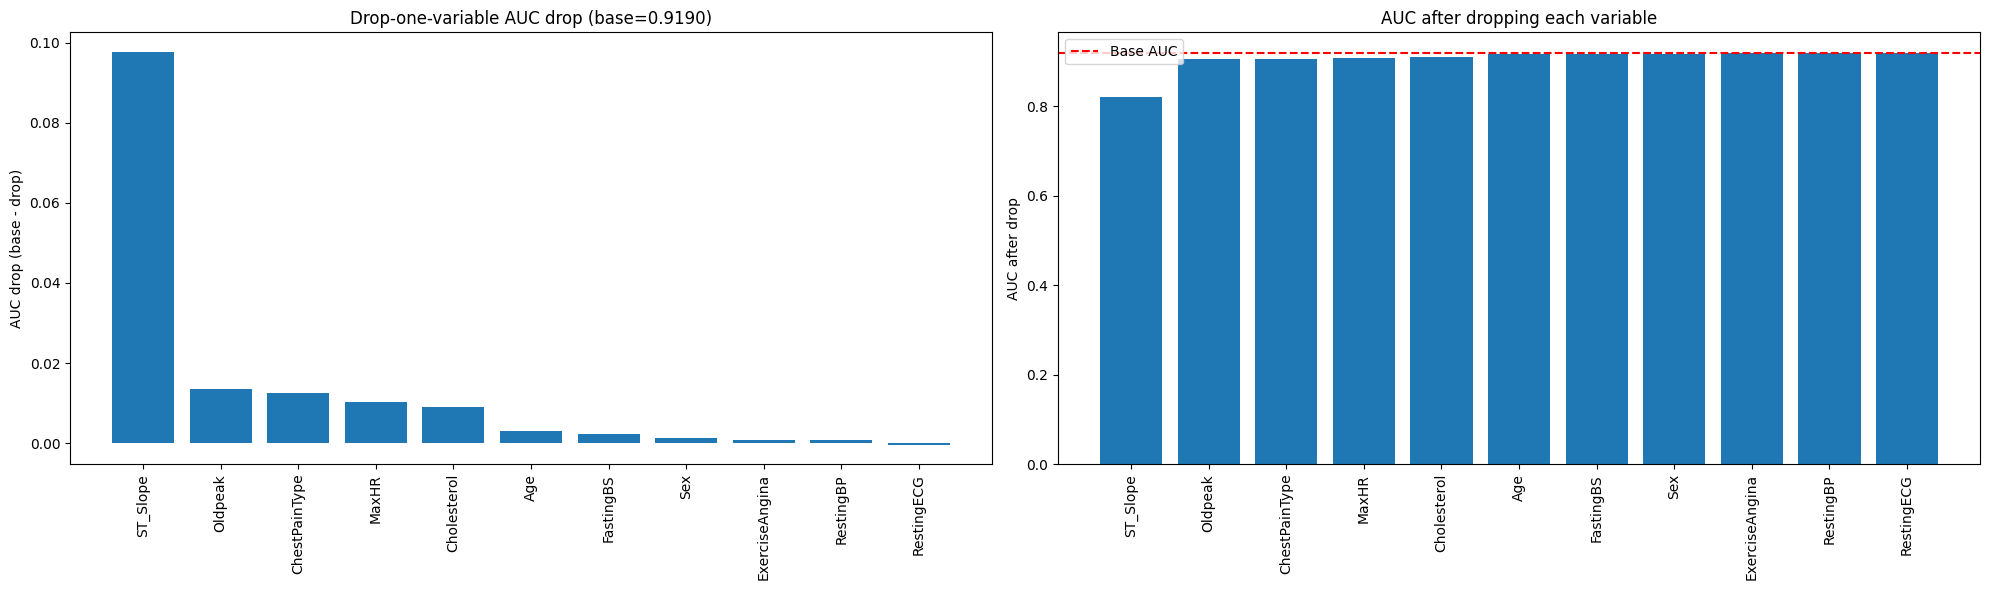

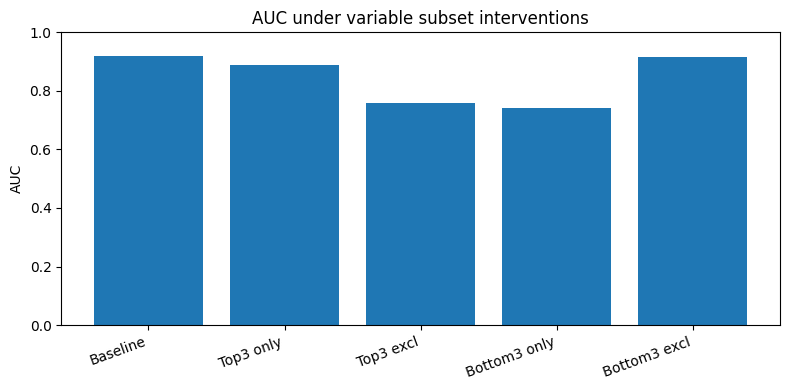

In [34]:
res = run_drop(model, loader, mode="drop", src_idx=0)
plot_drop(res)
out = run_kbars(model, loader, k=3, res=res, mode="drop", src_idx=0)


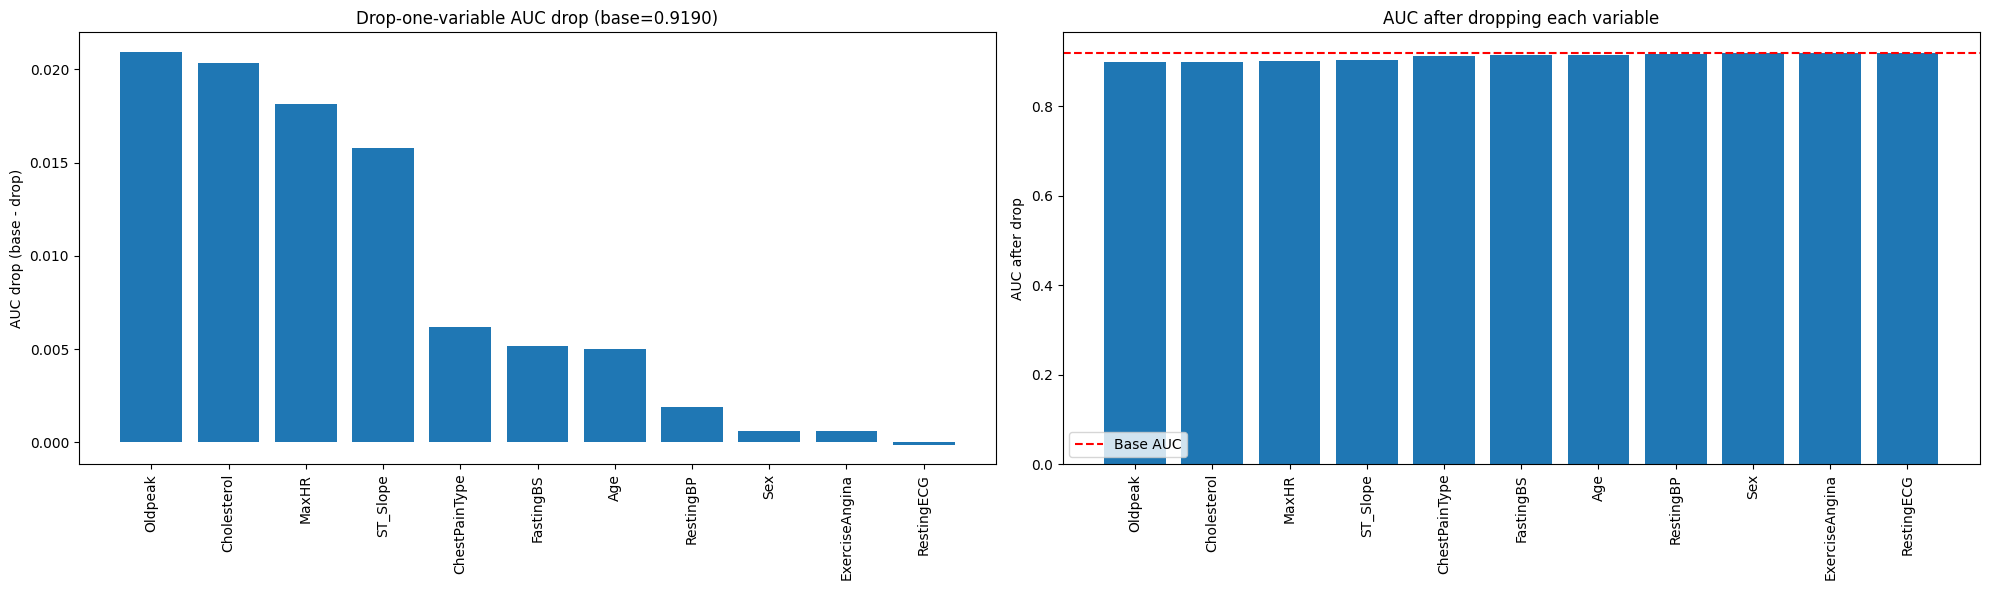

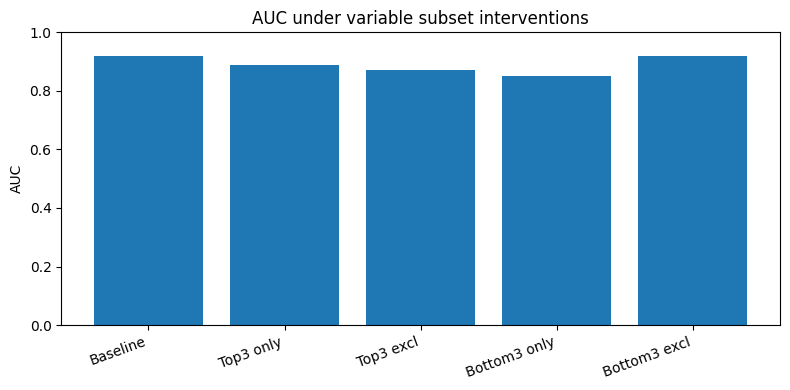

In [46]:
res = run_drop(model, loader, mode="rep", src_idx=0)
plot_drop(res)
out = run_kbars(model, loader, k=3, res=res, mode="rep", src_idx=0)


## Qualitative Analysis (4) 
- Edge masking : CLS-> Var (1 : N) 
- Feature Selection과 동일한 상황 

unique y: [0 1] pos-rate: 0.5533769063180828
AUC(sigmoid(pred)): 0.919003264835798
AUC(1 - sigmoid(pred)): 0.08099673516420204


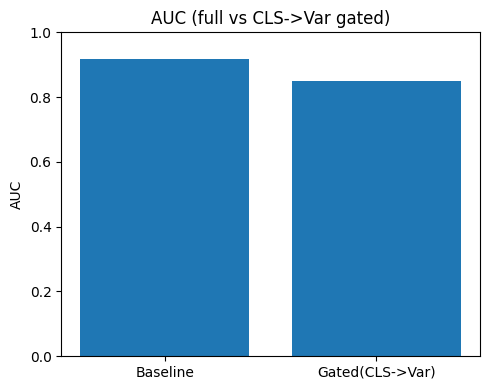

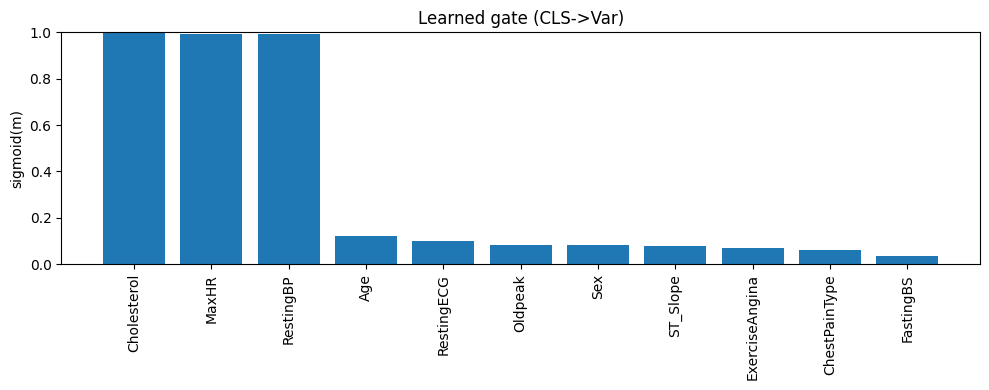

In [43]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

def auc_full(model, loader, device, src_idx=None, verbose=False):
    """
    src_idx가 주어지면: batch에 src_idx를 주입해서 sheads로 강제 평가
    src_idx가 None이면: batch에 src_idx 없으면 thead로 감 (원래 동작)
    """
    model.eval()
    yt, yp = [], []
    with torch.no_grad():
        for batch in loader:
            if src_idx is not None:
                batch["src_idx"] = src_idx
            else:
                if ('src_idx' not in batch) and verbose:
                    print("[WARN] batch에 src_idx 없음 -> predict()가 thead 사용함")

            pred = model.predict(batch)  # [B,1] logit (binary)
            y = batch['y'].detach().cpu().numpy().reshape(-1)        # 0/1
            p = torch.sigmoid(pred).detach().cpu().numpy().reshape(-1)

            yt.append(y); yp.append(p)

    yt = np.concatenate(yt, axis=0)
    yp = np.concatenate(yp, axis=0)

    auc_p = roc_auc_score(yt, yp)
    if verbose:
        auc_inv = roc_auc_score(yt, 1.0 - yp)
        print("unique y:", np.unique(yt), "pos-rate:", yt.mean())
        print("AUC(sigmoid(pred)):", auc_p)
        print("AUC(1 - sigmoid(pred)):", auc_inv)

    return auc_p

def mk_G_cls(m, B, T, device, tau=0.1):
    s = torch.sigmoid(m)
    hard = (s > tau).float()
    s_st = hard + (s - s.detach())     # forward=hard, backward=s
    g = torch.ones(B, T, T, device=device)
    g[:, 0, 1:] = s_st.unsqueeze(0).expand(B, -1)
    return g

def set_G(model, G):
    # 모든 basis layer에 동일 gate 주입
    for l in range(model.num_basis_layers):
        model.basis_layers[l].ovr_G = G

def clr_G(model):
    for l in range(model.num_basis_layers):
        model.basis_layers[l].ovr_G = None
        model.basis_layers[l].ovr_M = None  # 혹시 남아있으면 제거

def tr_cls_gate(model, loader, device, src_idx=None, iters=200, lr=0.2, lam=1e-3, gate_tau=0.5):
    """
    src_idx가 주어지면: gate 학습도 sheads 기준으로 돌아가도록 강제
    """
    model.eval()
    for p in model.parameters():
        p.requires_grad = False

    batch0 = next(iter(loader))
    names = extract_feature_names(batch0)
    S = len(names)
    T = S + 1

    m = torch.nn.Parameter(torch.zeros(S, device=device))
    opt = torch.optim.Adam([m], lr=lr)

    crit = model.criterion  # BCEWithLogitsLoss
    step = 0
    while step < iters:
        for batch in loader:
            if step >= iters:
                break
            opt.zero_grad()

            if src_idx is not None:
                batch["src_idx"] = src_idx  # ✅ 핵심

            B = batch['y'].shape[0]
            G = mk_G_cls(m, B, T, device, tau=gate_tau)
            set_G(model, G)

            pred = model.predict(batch)
            # binary classification: target shape [B,1] float
            y = batch['y'].to(device).view(-1, 1).float()
            loss = crit(pred, y) + lam * torch.sigmoid(m).sum()

            loss.backward()
            opt.step()
            step += 1

    clr_G(model)
    return m.detach(), ["CLS"] + names

def ev_cls_gate(model, loader, device, m, src_idx=None, gate_tau=0.5):
    """
    src_idx가 주어지면: gate 평가도 sheads 기준으로 강제
    """
    model.eval()
    yt, yp = [], []

    batch0 = next(iter(loader))
    names = ["CLS"] + extract_feature_names(batch0)
    S = len(names) - 1
    T = S + 1

    with torch.no_grad():
        for batch in loader:
            if src_idx is not None:
                batch["src_idx"] = src_idx  # ✅ 핵심

            B = batch['y'].shape[0]
            G = mk_G_cls(m, B, T, device, tau=gate_tau)
            set_G(model, G)

            pred = model.predict(batch)
            yt.extend(batch['y'].detach().cpu().numpy().reshape(-1).tolist())
            yp.extend(torch.sigmoid(pred).detach().cpu().numpy().reshape(-1).tolist())

    clr_G(model)
    return roc_auc_score(np.array(yt), np.array(yp)), names

def plot_gate(m, names, title="CLS->Var gate"):
    g = torch.sigmoid(m).detach().cpu().numpy()
    labs = names[1:]
    order = np.argsort(-g)

    plt.figure(figsize=(max(10, 0.45*len(labs)), 4))
    plt.bar(np.arange(len(labs)), g[order])
    plt.xticks(np.arange(len(labs)), np.array(labs)[order], rotation=90)
    plt.ylim(0, 1)
    plt.ylabel("sigmoid(m)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def run_cls_gate(model, loader, device, src_idx=None, iters=200, lr=0.2, lam=1e-3, gate_tau=0.5, verbose_base=True):
    """
    src_idx:
      - None: 기존처럼 batch에 src_idx 없으면 thead로 감
      - int: 무조건 sheads[src_idx]로 평가/학습
    """
    base = auc_full(model, loader, device, src_idx=src_idx, verbose=verbose_base)

    m, names = tr_cls_gate(
        model, loader, device,
        src_idx=src_idx,
        iters=iters, lr=lr, lam=lam,
        gate_tau=gate_tau
    )
    auc_g, _ = ev_cls_gate(model, loader, device, m, src_idx=src_idx, gate_tau=gate_tau)

    plt.figure(figsize=(5,4))
    plt.bar([0,1], [base, auc_g])
    plt.xticks([0,1], ["Baseline", "Gated(CLS->Var)"])
    plt.ylim(0,1)
    plt.ylabel("AUC")
    plt.title("AUC (full vs CLS->Var gated)")
    plt.tight_layout()
    plt.show()

    plot_gate(m, names, title="Learned gate (CLS->Var)")
    return {"base_auc": float(base), "gated_auc": float(auc_g), "m": m, "names": names}

# 실행 예시:
# sources[0]이 지금 loader의 source라면 src_idx=0 넣어라.
outA = run_cls_gate(model, loader, device, src_idx=0, iters=200, lr=0.2, lam=0.1, gate_tau=0.2)


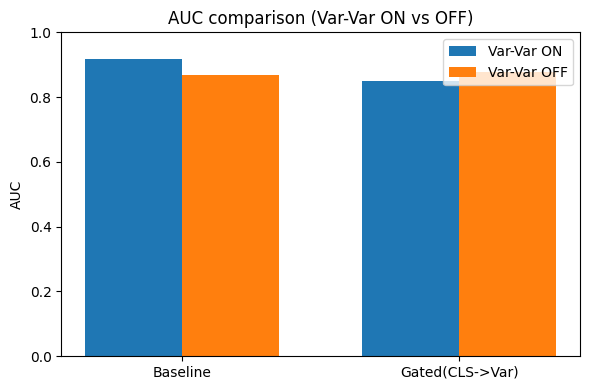

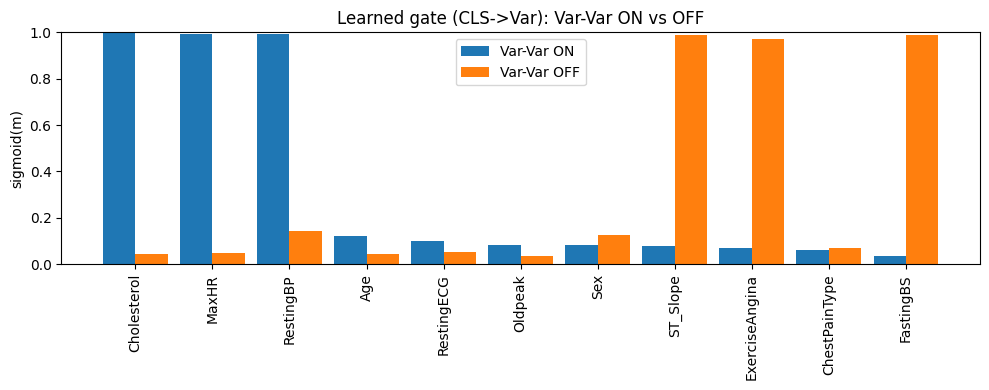

0.919003264835798 0.8503168811215671 0.8676781256001536 0.8769228922604188


In [47]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# -----------------------
# util: set/clear gate
# -----------------------
def set_G(model, G):
    for l in range(model.num_basis_layers):
        model.basis_layers[l].ovr_G = G

def clr_G(model):
    for l in range(model.num_basis_layers):
        model.basis_layers[l].ovr_G = None
        model.basis_layers[l].ovr_M = None
def mk_G_baseline(B, T, device):
    # override gate = all ones (masking 없음)
    return torch.ones(B, T, T, device=device)

def mk_G_vv_off_self(B, T, device, cls_on=1.0):
    # Var-Var OFF: self-loop만 허용
    # CLS->Var는 cls_on(1.0 keep / 0.0 block)
    G = torch.zeros(B, T, T, device=device)
    eye = torch.eye(T, device=device).unsqueeze(0).expand(B, -1, -1)
    G[:] = eye
    G[:, 0, 0] = 1.0
    G[:, 0, 1:] = float(cls_on)
    return G

def mk_G_cls_gate(B, T, device, m, vv_mode="full", tau=0.2):
    # m: [S] (S = T-1)
    s = torch.sigmoid(m)              # [S]
    hard = (s > tau).float()
    s_st = hard + (s - s.detach())    # STE

    G = torch.ones(B, T, T, device=device)
    G[:, 0, 1:] = s_st.unsqueeze(0).expand(B, -1)

    if vv_mode == "off":
        # Var-Var self only
        eye = torch.eye(T, device=device).unsqueeze(0).expand(B, -1, -1)
        G[:, 1:, 1:] = eye[:, 1:, 1:]
    return G
# -----------------------
# AUC under a given G maker
# -----------------------
@torch.no_grad()
def auc_with_Gmaker(model, loader, device, G_maker, T, src_idx=0):
    model.eval()
    yt, yp = [], []
    for batch in loader:
        batch = dict(batch)
        batch["src_idx"] = int(src_idx)   # ✅ 핵심

        B = batch["y"].shape[0]
        G = G_maker(B)                    # G_maker가 이미 device 만들면 .to(device) 불필요
        set_G(model, G)
        pred = model.predict(batch)

        yt.extend(batch["y"].detach().cpu().numpy().reshape(-1).tolist())
        yp.extend(torch.sigmoid(pred).detach().cpu().numpy().reshape(-1).tolist())

    clr_G(model)
    return roc_auc_score(np.array(yt), np.array(yp))


# -----------------------
# Train CLS gate (✅ src_idx 강제 주입)
# -----------------------
def tr_cls_gate_vv(model, loader, device, vv_mode="full", iters=200, lr=0.2, lam=1e-3, src_idx=0):
    model.eval()
    for p in model.parameters():
        p.requires_grad = False

    batch0 = next(iter(loader))
    names = extract_feature_names(batch0)
    S = len(names)
    T = S + 1

    m = torch.nn.Parameter(torch.zeros(S, device=device))
    opt = torch.optim.Adam([m], lr=lr)
    crit = model.criterion

    step = 0
    while step < iters:
        for batch in loader:
            if step >= iters:
                break
            batch = dict(batch)
            batch["src_idx"] = int(src_idx)  # ✅ 핵심

            opt.zero_grad()
            B = batch["y"].shape[0]
            G = mk_G_cls_gate(B, T, device, m, vv_mode=vv_mode)
            set_G(model, G)

            pred = model.predict(batch)
            y = batch["y"].to(device).view(-1, 1).float() if model.num_classes == 2 else batch["y"].to(device).long()
            loss = crit(pred, y) + lam * torch.sigmoid(m).sum()

            loss.backward()
            opt.step()
            step += 1

    clr_G(model)
    return m.detach(), ["CLS"] + names


# -----------------------
# Evaluate learned m (✅ src_idx 강제 주입)
# -----------------------
@torch.no_grad()
def ev_cls_gate_vv(model, loader, device, m, vv_mode="full", src_idx=0):
    model.eval()
    yt, yp = [], []
    batch0 = next(iter(loader))
    names = ["CLS"] + extract_feature_names(batch0)
    S = len(names) - 1
    T = S + 1

    for batch in loader:
        batch = dict(batch)
        batch["src_idx"] = int(src_idx)   # ✅ 핵심

        B = batch["y"].shape[0]
        G = mk_G_cls_gate(B, T, device, m, vv_mode=vv_mode)
        set_G(model, G)

        pred = model.predict(batch)
        yt.extend(batch["y"].detach().cpu().numpy().reshape(-1).tolist())
        yp.extend(torch.sigmoid(pred).detach().cpu().numpy().reshape(-1).tolist())

    clr_G(model)
    return roc_auc_score(np.array(yt), np.array(yp)), names
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_auc_compare(base_on, gated_on, base_off, gated_off):
    plt.figure(figsize=(6,4))
    x = np.array([0, 1])  # Baseline, Gated
    w = 0.35
    plt.bar(x - w/2, [base_on, gated_on], width=w, label="Var-Var ON")
    plt.bar(x + w/2, [base_off, gated_off], width=w, label="Var-Var OFF")
    plt.xticks(x, ["Baseline", "Gated(CLS->Var)"])
    plt.ylim(0, 1)
    plt.ylabel("AUC")
    plt.title("AUC comparison (Var-Var ON vs OFF)")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_gate_compare(m_on, m_off, names, title="Learned gate (CLS->Var)"):
    g_on  = torch.sigmoid(m_on).detach().cpu().numpy()
    g_off = torch.sigmoid(m_off).detach().cpu().numpy()
    labs = np.array(names[1:])  # drop CLS

    order = np.argsort(-g_on)   # ON 기준 정렬
    g_on, g_off, labs = g_on[order], g_off[order], labs[order]

    x = np.arange(len(labs))
    w = 0.42
    plt.figure(figsize=(max(10, 0.45*len(labs)), 4))
    plt.bar(x - w/2, g_on,  width=w, label="Var-Var ON")
    plt.bar(x + w/2, g_off, width=w, label="Var-Var OFF")
    plt.xticks(x, labs, rotation=90)
    plt.ylim(0, 1)
    plt.ylabel("sigmoid(m)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# -----------------------
# Main runner (✅ src_idx 인자로 받기)
# -----------------------
def run_cls_gate_compare_vv(model, loader, device, iters=200, lr=0.2, lam=1e-3, src_idx=0):
    batch0 = next(iter(loader))
    names = extract_feature_names(batch0)
    S = len(names)
    T = S + 1

    base_on  = auc_with_Gmaker(model, loader, device, lambda B: mk_G_baseline(B, T, device), T, src_idx=src_idx)
    base_off = auc_with_Gmaker(model, loader, device, lambda B: mk_G_vv_off_self(B, T, device, cls_on=1.0), T, src_idx=src_idx)

    m_on,  full_names = tr_cls_gate_vv(model, loader, device, vv_mode="full", iters=iters, lr=lr, lam=lam, src_idx=src_idx)
    m_off, _          = tr_cls_gate_vv(model, loader, device, vv_mode="off",  iters=iters, lr=lr, lam=lam, src_idx=src_idx)

    gated_on,  _ = ev_cls_gate_vv(model, loader, device, m_on,  vv_mode="full", src_idx=src_idx)
    gated_off, _ = ev_cls_gate_vv(model, loader, device, m_off, vv_mode="off",  src_idx=src_idx)

    plot_auc_compare(base_on, gated_on, base_off, gated_off)
    plot_gate_compare(m_on, m_off, full_names, title="Learned gate (CLS->Var): Var-Var ON vs OFF")

    return {
        "base_auc_vv_on": float(base_on),
        "base_auc_vv_off": float(base_off),
        "gated_auc_vv_on": float(gated_on),
        "gated_auc_vv_off": float(gated_off),
        "m_vv_on": m_on,
        "m_vv_off": m_off,
        "names": full_names,
    }

# ---- 실행 ----
out = run_cls_gate_compare_vv(model, loader, device, iters=200, lr=0.2, lam=0.1, src_idx=0)
print(out["base_auc_vv_on"], out["gated_auc_vv_on"], out["base_auc_vv_off"], out["gated_auc_vv_off"])



## Qualitative Analysis (6) 

- Var-to-Var adjacency All pruning (sanity check)
- Leave-One-Out and Var-to-Var Attention 
- Selected Subgraph + Point
- Selected Subgraph + complementary Subgraph

Computing metrics...


/tmp/ipykernel_2626598/981498542.py:170: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax[2].boxplot([sub_on, sub_off], patch_artist=True, labels=['CLS→Var ON', 'CLS→Var OFF'])
/tmp/ipykernel_2626598/981498542.py:181: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp4 = ax[3].boxplot([two_on, two_off], patch_artist=True, labels=['CLS→Var ON', 'CLS→Var OFF'])


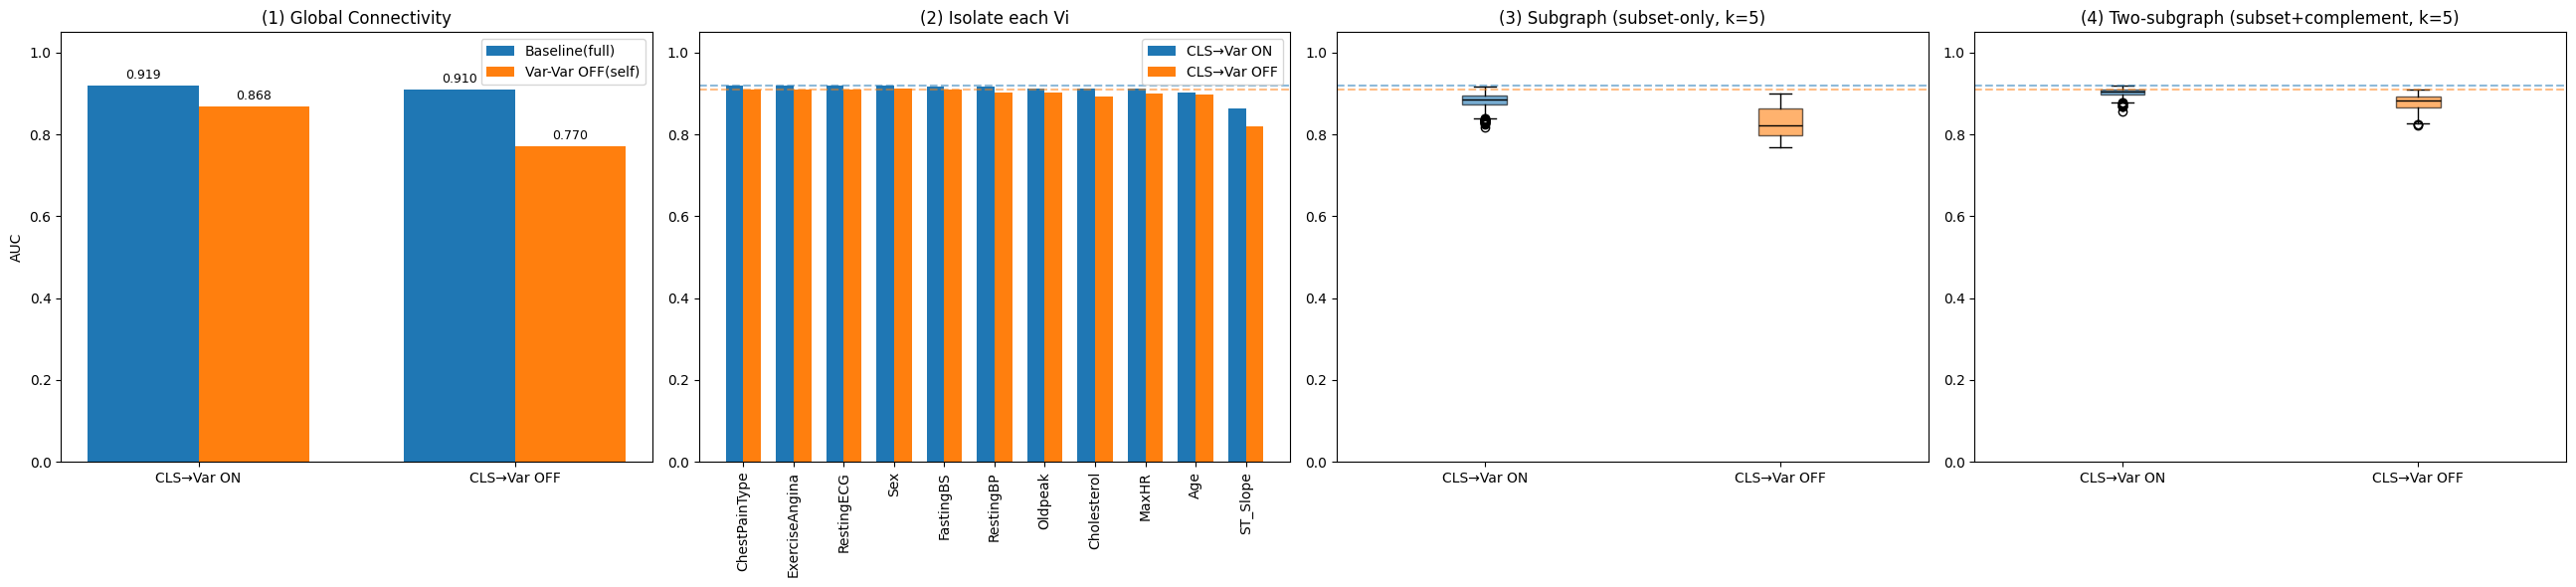

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.metrics import roc_auc_score

# ----------------------------
# Helper Functions
# ----------------------------
def _setG(model, G):
    for l in range(model.num_basis_layers):
        model.basis_layers[l].ovr_G = G

def _clrG(model):
    for l in range(model.num_basis_layers):
        model.basis_layers[l].ovr_G = None
        model.basis_layers[l].ovr_M = None

def _mkG(B, T, device, cls_on=True, vv_mode="full", iso_i=None, sub_idx=None):
    g = torch.ones(B, T, T, device=device)

    # CLS->Var
    g[:,1:,0] = 0.0 # Var->CLS always off 
    g[:,0,0] = 1.0


    g[:, 0, 1:] = 1.0 if cls_on else 0.0

    if vv_mode == "off":
        eye = torch.eye(T, device=device).unsqueeze(0).expand(B, -1, -1)
        g[:, 1:, 1:] = eye[:, 1:, 1:]

    elif vv_mode == "iso":
        # isolate variable i from other vars (var-var only)
        t = 1 + int(iso_i)
        g[:, t, 1:] = 0.0
        g[:, 1:, t] = 0.0
        g[:, t, t] = 1.0
        # 원하면 완전 isolate (CLS→Vi도 끊기):
        # g[:, 0, t] = 0.0

    elif vv_mode == "sub":
        # self-only everywhere, then allow full connectivity inside subset only
        eye = torch.eye(T, device=device).unsqueeze(0).expand(B, -1, -1)
        g[:, 1:, 1:] = eye[:, 1:, 1:]
        idx = torch.tensor([1 + int(i) for i in sub_idx], device=device)
        g[:, idx[:, None], idx[None, :]] = 1.0

    elif vv_mode == "two_sub":
        # NEW: block-diagonal two subgraphs (subset + complement), no cross edges
        eye = torch.eye(T, device=device).unsqueeze(0).expand(B, -1, -1)
        g[:, 1:, 1:] = 0.0          # start from zero among vars
        g[:, 1:, 1:] += eye[:, 1:, 1:]  # keep self-loop at least

        sub = set(int(i) for i in sub_idx)
        comp = [i for i in range(T-1) if i not in sub]  # over vars indices 0..S-1

        idx_sub  = torch.tensor([1 + i for i in sorted(list(sub))], device=device, dtype=torch.long)
        idx_comp = torch.tensor([1 + i for i in comp], device=device, dtype=torch.long)

        if idx_sub.numel() > 0:
            g[:, idx_sub[:, None], idx_sub[None, :]] = 1.0
        if idx_comp.numel() > 0:
            g[:, idx_comp[:, None], idx_comp[None, :]] = 1.0

        # NOTE: CLS->Var는 위에서 cls_on에 의해 이미 on/off 됨
        # 그리고 subset<->complement var-var는 0으로 유지됨 (cross blocked)

    return g

@torch.no_grad()
def _aucG(model, loader, device, names, cls_on=True, vv_mode="full", iso_i=None, sub_idx=None, src_idx=None):
    model.eval()
    yt, yp = [], []
    S = len(names); T = S + 1

    for batch in loader:
        batch = dict(batch)
        if src_idx is not None:
            batch["src_idx"] = int(src_idx)

        B = batch["y"].shape[0]
        G = _mkG(B, T, device, cls_on=cls_on, vv_mode=vv_mode, iso_i=iso_i, sub_idx=sub_idx)
        _setG(model, G)

        pred = model.predict(batch)
        yt.extend(batch["y"].cpu().numpy().reshape(-1).tolist())
        yp.extend(torch.sigmoid(pred).detach().cpu().numpy().reshape(-1).tolist())

    _clrG(model)
    return roc_auc_score(np.array(yt), np.array(yp))

# ----------------------------
# Main Runner (1 row x 4 cols)
# ----------------------------
def run_1x4_all(model, loader, device, k=2, src_idx=None):
    b0 = next(iter(loader))
    names = np.array(extract_feature_names(b0))
    S = len(names)

    print("Computing metrics...")

    # (A) CLS ON Group
    base_on = _aucG(model, loader, device, names, cls_on=True,  vv_mode="full", src_idx=src_idx)
    vvo_on  = _aucG(model, loader, device, names, cls_on=True,  vv_mode="off",  src_idx=src_idx)

    # (B) CLS OFF Group
    base_off = _aucG(model, loader, device, names, cls_on=False, vv_mode="full", src_idx=src_idx)
    vvo_off  = _aucG(model, loader, device, names, cls_on=False, vv_mode="off",  src_idx=src_idx)

    # (C) Isolate each Vi (ON vs OFF)
    iso_on, iso_off = [], []
    for i in range(S):
        iso_on.append(_aucG(model, loader, device, names, cls_on=True,  vv_mode="iso", iso_i=i, src_idx=src_idx))
        iso_off.append(_aucG(model, loader, device, names, cls_on=False, vv_mode="iso", iso_i=i, src_idx=src_idx))
    iso_on  = np.array(iso_on)
    iso_off = np.array(iso_off)

    # (D) Subset Interaction (subset-only var-var)
    sub_on, sub_off = [], []
    for comb in combinations(range(S), k):
        sub_on.append(_aucG(model, loader, device, names, cls_on=True,  vv_mode="sub", sub_idx=comb, src_idx=src_idx))
        sub_off.append(_aucG(model, loader, device, names, cls_on=False, vv_mode="sub", sub_idx=comb, src_idx=src_idx))
    sub_on  = np.array(sub_on)
    sub_off = np.array(sub_off)

    # (E) NEW: block-diagonal two-subgraph (subset + complement)
    two_on, two_off = [], []
    for comb in combinations(range(S), k):
        two_on.append(_aucG(model, loader, device, names, cls_on=True,  vv_mode="two_sub", sub_idx=comb, src_idx=src_idx))
        two_off.append(_aucG(model, loader, device, names, cls_on=False, vv_mode="two_sub", sub_idx=comb, src_idx=src_idx))
    two_on  = np.array(two_on)
    two_off = np.array(two_off)

    # ----------------------------
    # Plot (1 Row x 4 Columns)
    # ----------------------------
    fig, ax = plt.subplots(1, 4, figsize=(26, 6))
    c_on = 'tab:blue'
    c_off = 'tab:orange'
    bar_width = 0.35

    # (1) Global Connectivity
    x_pos = np.arange(2)
    means_base = [base_on, base_off]
    means_vvo  = [vvo_on, vvo_off]
    ax[0].bar(x_pos - bar_width/2, means_base, width=bar_width, label='Baseline(full)', color=c_on)
    ax[0].bar(x_pos + bar_width/2, means_vvo,  width=bar_width, label='Var-Var OFF(self)', color=c_off)
    ax[0].set_xticks(x_pos)
    ax[0].set_xticklabels(["CLS→Var ON", "CLS→Var OFF"])
    ax[0].set_ylim(0, 1.05)
    ax[0].set_ylabel("AUC")
    ax[0].set_title("(1) Global Connectivity")
    ax[0].legend()
    for i, v in enumerate(means_base):
        ax[0].text(i - bar_width/2, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=9)
    for i, v in enumerate(means_vvo):
        ax[0].text(i + bar_width/2, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontsize=9)

    # (2) Isolate each Vi (Sorted by ON)
    order = np.argsort(-iso_on)
    x2 = np.arange(S)
    ax[1].bar(x2 - bar_width/2, iso_on[order],  width=bar_width, color=c_on,  label='CLS→Var ON')
    ax[1].bar(x2 + bar_width/2, iso_off[order], width=bar_width, color=c_off, label='CLS→Var OFF')
    ax[1].axhline(base_on,  color=c_on,  linestyle="--", alpha=0.5)
    ax[1].axhline(base_off, color=c_off, linestyle="--", alpha=0.5)
    ax[1].set_xticks(x2)
    ax[1].set_xticklabels(names[order], rotation=90)
    ax[1].set_ylim(0, 1.05)
    ax[1].set_title("(2) Isolate each Vi")
    ax[1].legend()

    # (3) Subset-only Var-Var
    bp3 = ax[2].boxplot([sub_on, sub_off], patch_artist=True, labels=['CLS→Var ON', 'CLS→Var OFF'])
    for patch, col in zip(bp3['boxes'], [c_on, c_off]):
        patch.set_facecolor(col); patch.set_alpha(0.6)
    for med in bp3['medians']:
        med.set_color('black')
    ax[2].axhline(base_on,  color=c_on,  linestyle="--", alpha=0.5)
    ax[2].axhline(base_off, color=c_off, linestyle="--", alpha=0.5)
    ax[2].set_ylim(0, 1.05)
    ax[2].set_title(f"(3) Subgraph (subset-only, k={k})")

    # (4) Two-subgraph block-diagonal
    bp4 = ax[3].boxplot([two_on, two_off], patch_artist=True, labels=['CLS→Var ON', 'CLS→Var OFF'])
    for patch, col in zip(bp4['boxes'], [c_on, c_off]):
        patch.set_facecolor(col); patch.set_alpha(0.6)
    for med in bp4['medians']:
        med.set_color('black')
    ax[3].axhline(base_on,  color=c_on,  linestyle="--", alpha=0.5)
    ax[3].axhline(base_off, color=c_off, linestyle="--", alpha=0.5)
    ax[3].set_ylim(0, 1.05)
    ax[3].set_title(f"(4) Two-subgraph (subset+complement, k={k})")

    plt.tight_layout()
    plt.show()

    return {
        "names": names, "k": k,
        "base_on": float(base_on), "vvo_on": float(vvo_on),
        "base_off": float(base_off), "vvo_off": float(vvo_off),
        "iso_on": iso_on, "iso_off": iso_off,
        "sub_on": sub_on, "sub_off": sub_off,
        "two_on": two_on, "two_off": two_off
    }

# 실행 예시
out = run_1x4_all(model, loader, device, k=5, src_idx=0)


In [51]:
# S, T 잡기
b0 = next(iter(loader))
names = extract_feature_names(b0)   # 너가 이미 쓰던 함수
S = len(names)
T = S + 1

# 한 배치 크기(B)로 G 만들고 확인
G = _mkG(B=1, T=T, device=device, cls_on=False, vv_mode="full")

print("CLS->Var unique:", G[0, 0, 1:].unique())   # [0]이면 CLS->Var 차단
print("Var->CLS unique:", G[0, 1:, 0].unique())   # [1]이면 Var->CLS는 살아있음
print("CLS self:", G[0,0,0].item())


CLS->Var unique: tensor([0.], device='cuda:0')
Var->CLS unique: tensor([1.], device='cuda:0')
CLS self: 1.0
